# CSIT 598 - Assignment 1
## 05. k-Nearest Neighbors (k-NN)

Implementation of  k-NN, evaluating multiple k values, and finding optimal k.

In [5]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from utils import evaluate_classifier, plot_confusion

In [6]:
project_root = Path.cwd().parent
artifact_path = project_root / 'results' / 'metrics' / 'mnist_splits.npz'

if not artifact_path.exists():
    raise FileNotFoundError(
        f"Missing artifact: {artifact_path}. Run 01_data_preprocessing.ipynb first."
    )

data = dict(np.load(artifact_path))
X_train_std, y_train = data['X_train_std'], data['y_train']
X_val_std, y_val = data['X_val_std'], data['y_val']
X_test_std, y_test = data['X_test_std'], data['y_test']

print('Loaded standardized data:')
print(f'X_train: {X_train_std.shape}, X_val: {X_val_std.shape}, X_test: {X_test_std.shape}')

Loaded standardized data:
X_train: (50000, 784), X_val: (10000, 784), X_test: (10000, 784)


In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
val_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    model.fit(X_train_std, y_train)
    val_acc = model.score(X_val_std, y_val)
    val_scores.append(val_acc)
    print(f'k={k:>2} | validation accuracy={val_acc:.4f}')

best_idx = int(np.argmax(val_scores))
best_k = k_values[best_idx]
best_val_acc = float(val_scores[best_idx])

print(f'\nBest k from validation set: {best_k} (accuracy={best_val_acc:.4f})')

# Final train on train+val with best k, evaluate on test
X_trainval_std = np.vstack([X_train_std, X_val_std])
y_trainval = np.concatenate([y_train, y_val])

best_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1)
knn_metrics = evaluate_classifier(
    best_knn, X_trainval_std, y_trainval, X_test_std, y_test
)

print('\nk-NN Test Metrics:')
print(f"Accuracy: {knn_metrics['accuracy']:.4f}")
print(f"Precision (macro): {knn_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {knn_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {knn_metrics['f1_macro']:.4f}")
print(f"Train time (s): {knn_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {knn_metrics['pred_time_sec']:.2f}")

k= 1 | validation accuracy=0.9481
k= 3 | validation accuracy=0.9500
k= 5 | validation accuracy=0.9497
k= 7 | validation accuracy=0.9488
k= 9 | validation accuracy=0.9462
k=11 | validation accuracy=0.9444
k=15 | validation accuracy=0.9415
k=20 | validation accuracy=0.9389

Best k from validation set: 3 (accuracy=0.9500)

k-NN Test Metrics:
Accuracy: 0.9483
Precision (macro): 0.9487
Recall (macro): 0.9476
F1 (macro): 0.9478
Train time (s): 0.03
Pred time (s): 2.37


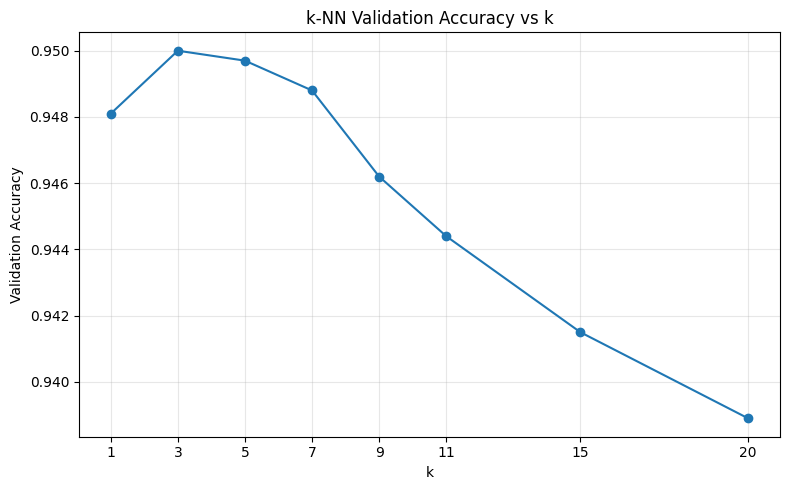

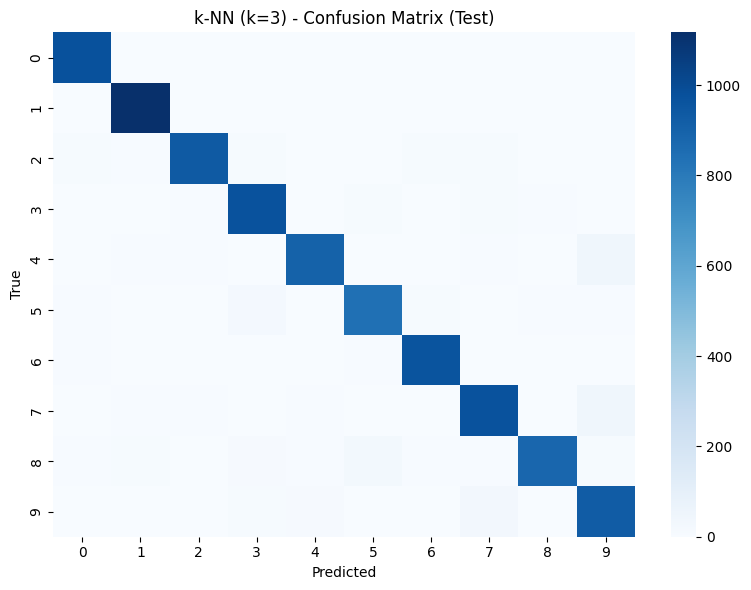


Classification report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       986
           1       0.97      0.99      0.98      1125
           2       0.97      0.94      0.95       999
           3       0.93      0.95      0.94      1020
           4       0.96      0.92      0.94       975
           5       0.94      0.93      0.93       902
           6       0.96      0.98      0.97       982
           7       0.93      0.93      0.93      1042
           8       0.97      0.91      0.94       975
           9       0.89      0.93      0.91       994

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000


Saved:
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/knn_metrics.json
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, val_scores, marker='o')
plt.title('k-NN Validation Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_confusion(y_test, knn_metrics['y_pred'], title=f'k-NN (k={best_k}) - Confusion Matrix (Test)')

metrics_dir = project_root / 'results' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

knn_to_save = {k: v for k, v in knn_metrics.items() if k != 'y_pred'}
knn_to_save['model_name'] = 'KNN'
knn_to_save['best_k'] = int(best_k)
knn_to_save['best_validation_accuracy'] = best_val_acc
knn_to_save['k_values'] = k_values
knn_to_save['validation_scores'] = [float(v) for v in val_scores]

with open(metrics_dir / 'knn_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(knn_to_save, f, indent=2)

with open(metrics_dir / 'knn_k_sweep.json', 'w', encoding='utf-8') as f:
    json.dump({
        'k_values': k_values,
        'validation_scores': [float(v) for v in val_scores],
        'best_k': int(best_k),
        'best_validation_accuracy': best_val_acc,
    }, f, indent=2)

print('\nClassification report:\n')
print(knn_metrics['classification_report'])
print('\nSaved:')
print(metrics_dir / 'knn_metrics.json')
print(metrics_dir / 'knn_k_sweep.json')